In [27]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [28]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [29]:
files_F222 = []
files_F223 = []
files_F231 = []
files_F232 = []
files_F241 = []
files_tungsten = []
files_F242 = []
files_caloNu = []
files_F243 = []

data_files = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])
    if runs_F222[0] <= run_num <= runs_F222[1]:
        files_F222.append(file)
    elif runs_F223[0] <= run_num <= runs_F223[1]:
        files_F223.append(file)
    elif runs_F231[0] <= run_num <= runs_F231[1]:
        files_F231.append(file)
    elif runs_F232[0] <= run_num <= runs_F232[1]:
        files_F232.append(file)
    elif runs_F241[0] <= run_num <= runs_F241[1]:
        files_F241.append(file)
    elif runs_tungsten[0] <= run_num <= runs_tungsten[1]:
        files_tungsten.append(file)
    elif runs_F242[0] <= run_num <= runs_F242[1]:
        files_F242.append(file)
    elif runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        files_caloNu.append(file)
    elif runs_F243[0] <= run_num <= runs_F243[1]:
        files_F243.append(file)

print(f"Files for F222: {len(files_F222)}")
print(f"Files for F223: {len(files_F223)}")
print(f"Files for F231: {len(files_F231)}")
print(f"Files for F232: {len(files_F232)}")
print(f"Files for F241: {len(files_F241)}")
print(f"Files for tungsten: {len(files_tungsten)}")
print(f"Files for F242: {len(files_F242)}")
print(f"Files for caloNu: {len(files_caloNu)}")
print(f"Files for F243: {len(files_F243)}")

Files for F222: 95
Files for F223: 83
Files for F231: 61
Files for F232: 28
Files for F241: 49
Files for tungsten: 43
Files for F242: 31
Files for caloNu: 130
Files for F243: 23


In [30]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [31]:
lumi_F222 = grl_df[grl_df["Run"].between(runs_F222[0], runs_F222[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F223 = grl_df[grl_df["Run"].between(runs_F223[0], runs_F223[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F231 = grl_df[grl_df["Run"].between(runs_F231[0], runs_F231[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F232 = grl_df[grl_df["Run"].between(runs_F232[0], runs_F232[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

lumi_F241 = grl_df[grl_df["Run"].between(runs_F241[0], runs_F241[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_tungsten = grl_df[grl_df["Run"].between(runs_tungsten[0], runs_tungsten[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F242 = grl_df[grl_df["Run"].between(runs_F242[0], runs_F242[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_caloNu = grl_df[grl_df["Run"].between(runs_caloNu[0], runs_caloNu[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F243 = grl_df[grl_df["Run"].between(runs_F243[0], runs_F243[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

print(f"Luminosity for F222: {lumi_F222:.3f} fb^-1")
print(f"Luminosity for F223: {lumi_F223:.3f} fb^-1")
print(f"Luminosity for F231: {lumi_F231:.3f} fb^-1")
print(f"Luminosity for F232: {lumi_F232:.3f} fb^-1")
print(f"Luminosity for F241: {lumi_F241:.3f} fb^-1")
print(f"Luminosity for tungsten: {lumi_tungsten:.3f} fb^-1")
print(f"Luminosity for F242: {lumi_F242:.3f} fb^-1")
print(f"Luminosity for caloNu: {lumi_caloNu:.3f} fb^-1")
print(f"Luminosity for F243: {lumi_F243:.3f} fb^-1")

Luminosity for F222: 9.700 fb^-1
Luminosity for F223: 27.289 fb^-1
Luminosity for F231: 20.473 fb^-1
Luminosity for F232: 9.225 fb^-1
Luminosity for F241: 11.522 fb^-1
Luminosity for tungsten: 17.449 fb^-1
Luminosity for F242: 9.772 fb^-1
Luminosity for caloNu: 70.033 fb^-1
Luminosity for F243: 11.354 fb^-1


In [40]:
# sub_folder = "MC_no_truth_cuts"
sub_folder = "MC_truth_cuts_more_hists"


MC_files_nominal = {
    "2022_2023_MC": {"file": f"build/{sub_folder}/2022_2023.bck.root", "rate": None},
    "2024_noCaloNu_MC": {"file": f"build/{sub_folder}/2024_noCaloNu.bck.root", "rate": None},
    "2024_withCaloNu_MC": {"file": f"build/{sub_folder}/2024_CaloNu.bck.root", "rate": None},
    "color": "blue",
}

MC_files_FTF_BIC = {
    "2022_2023_MC": {"file": f"build/{sub_folder}/2022_2023_FTF_BIC.bck.root", "rate": None},
    "2024_noCaloNu_MC": {"file": f"build/{sub_folder}/2024_noCaloNu_FTF_BIC.bck.root", "rate": None},
    "2024_withCaloNu_MC": {"file": f"build/{sub_folder}/2024_CaloNu_FTF_BIC.bck.root", "rate": None},
    "color": "green",
}

MC_FTFP_INCLXX_files = {
    "2022_2023_MC": {"file": f"build/{sub_folder}/2022_2023_FTFP_INCLXX.bck.root", "rate": None},
    "2024_noCaloNu_MC": {"file": f"build/{sub_folder}/2024_noCaloNu_FTFP_INCLXX.bck.root", "rate": None},
    "2024_withCaloNu_MC": {"file": f"build/{sub_folder}/2024_CaloNu_FTFP_INCLXX.bck.root", "rate": None},
    "color": "red",
}

MC_FTFP_BERT_HP_JEFF33_files = {
    "2022_2023_MC": {"file": f"build/{sub_folder}/2022_2023_FTFP_BERT_HP_JEFF33.bck.root", "rate": None},
    "2024_noCaloNu_MC": {"file": f"build/{sub_folder}/2024_noCaloNu_FTFP_BERT_HP_JEFF33.bck.root", "rate": None},
    "2024_withCaloNu_MC": {"file": f"build/{sub_folder}/2024_CaloNu_FTFP_BERT_HP_JEFF33.bck.root", "rate": None},
    "color": "orange",
}

MC_FTFP_BERT_HP_ENDFB8_files = {
    "2022_2023_MC": {"file": f"build/{sub_folder}/2022_2023_FTFP_BERT_HP_ENDFB8.bck.root", "rate": None},
    "2024_noCaloNu_MC": {"file": f"build/{sub_folder}/2024_noCaloNu_FTFP_BERT_HP_ENDFB8.bck.root", "rate": None},
    "2024_withCaloNu_MC": {"file": f"build/{sub_folder}/2024_CaloNu_FTFP_BERT_HP_ENDFB8.bck.root", "rate": None},
    "color": "purple"
}

In [41]:
MC_file_dict = {
    "nominal": MC_files_nominal,
    "FTF_BIC": MC_files_FTF_BIC,
    "FTFP_INCLXX": MC_FTFP_INCLXX_files,
    "FTFP_BERT_HP_JEFF33": MC_FTFP_BERT_HP_JEFF33_files,
    "FTFP_BERT_HP_ENDFB8": MC_FTFP_BERT_HP_ENDFB8_files
}

In [42]:
# # Plot reduced charge distributions for VetoNu0 and VetoNu1 for each MC file
# # 2022-2023:

# fig, ax = plt.subplots(figsize=(10, 6), ncols=2)

# for mc_name, mc_info in MC_file_dict.items():

#     files = [mc_info["2022_2023_MC"]["file"]]
#     files = [f"{f}:nt" for f in files]
#     data = uproot.concatenate(files, filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge"], library="np")

#     hist_VetoNu0 = bh.Histogram(bh.axis.Regular(2501, -1, 30), storage=bh.storage.Weight())
#     hist_VetoNu1 = bh.Histogram(bh.axis.Regular(2501, -1, 30), storage=bh.storage.Weight())
#     hist_VetoNu0.fill(data["VetoNu0_reduced_charge"])
#     hist_VetoNu1.fill(data["VetoNu1_reduced_charge"])




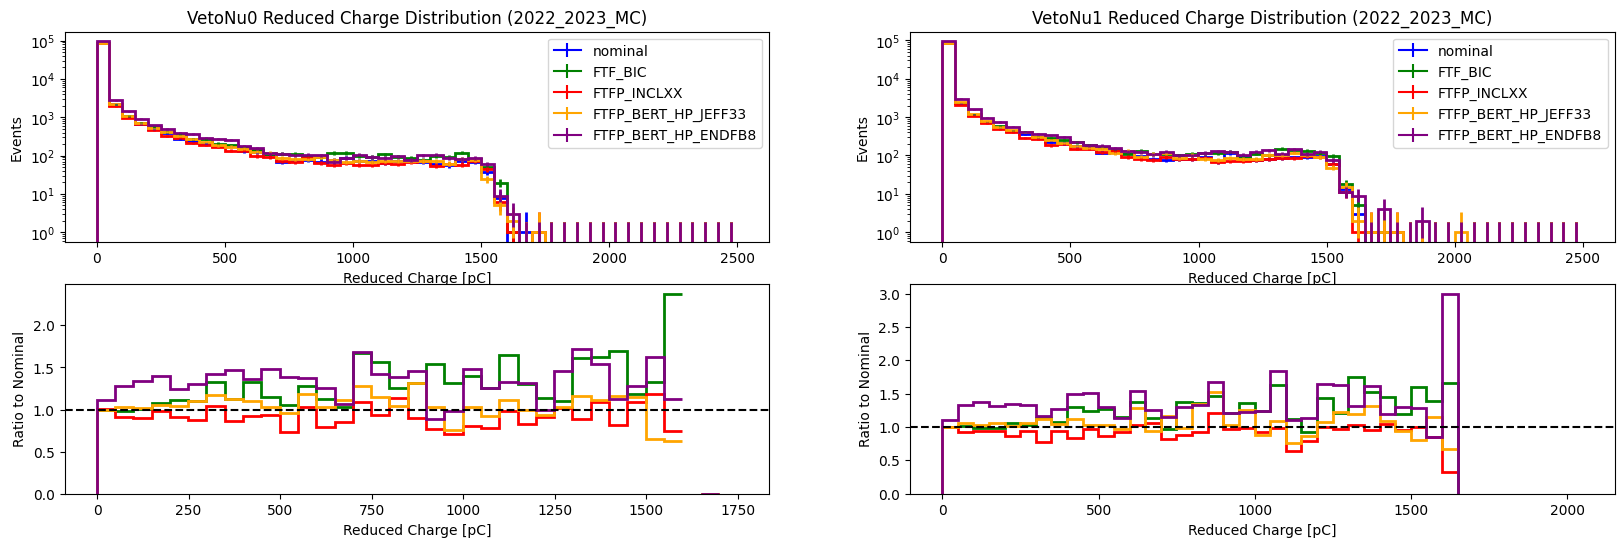

In [43]:
# Plot reduced charge distributions for VetoNu0 and VetoNu1 for each MC file
# 2022-2023:

fig, ax = plt.subplots(figsize=(20, 6), ncols=2, nrows=2)


h_VetoNu0_nom = None
h_VetoNu1_nom = None

rebin_factor = 50  # Adjust this factor as needed
period = "2022_2023_MC"

for mc_name, mc_info in MC_file_dict.items():

    file = mc_info[period]["file"]

    data = uproot.open(f"{file}:histograms")

    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    mplhep.histplot(h_VetoNu0, ax=ax[0][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(h_VetoNu1, ax=ax[0][1], label=mc_name, histtype="step", lw=2, color=color)

    if mc_name == "nominal":
        h_VetoNu0_nom = h_VetoNu0
        h_VetoNu1_nom = h_VetoNu1

for mc_name, mc_info in MC_file_dict.items():
    if mc_name == "nominal":
        continue

    file = mc_info[period]["file"]
    data = uproot.open(f"{file}:histograms")

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    ratio_VetoNu0 = h_VetoNu0 / h_VetoNu0_nom
    ratio_VetoNu1 = h_VetoNu1 / h_VetoNu1_nom

    mplhep.histplot(ratio_VetoNu0, ax=ax[1][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(ratio_VetoNu1, ax=ax[1][1], label=mc_name, histtype="step", lw=2, color=color)


ax[0][0].set_yscale("log")
ax[0][1].set_yscale("log")

ax[0][0].set_xlabel("Reduced Charge [pC]")
ax[0][1].set_xlabel("Reduced Charge [pC]")
ax[0][0].set_title(f"VetoNu0 Reduced Charge Distribution ({period})")
ax[0][1].set_title(f"VetoNu1 Reduced Charge Distribution ({period})")
ax[0][0].set_ylabel("Events")
ax[0][1].set_ylabel("Events")
ax[0][0].legend()
ax[0][1].legend();

ax[1][0].set_xlabel("Reduced Charge [pC]")
ax[1][1].set_xlabel("Reduced Charge [pC]")
ax[1][0].set_ylabel("Ratio to Nominal")
ax[1][1].set_ylabel("Ratio to Nominal")


ax[1][0].axhline(1, color="black", linestyle="--")
ax[1][1].axhline(1, color="black", linestyle="--")
    

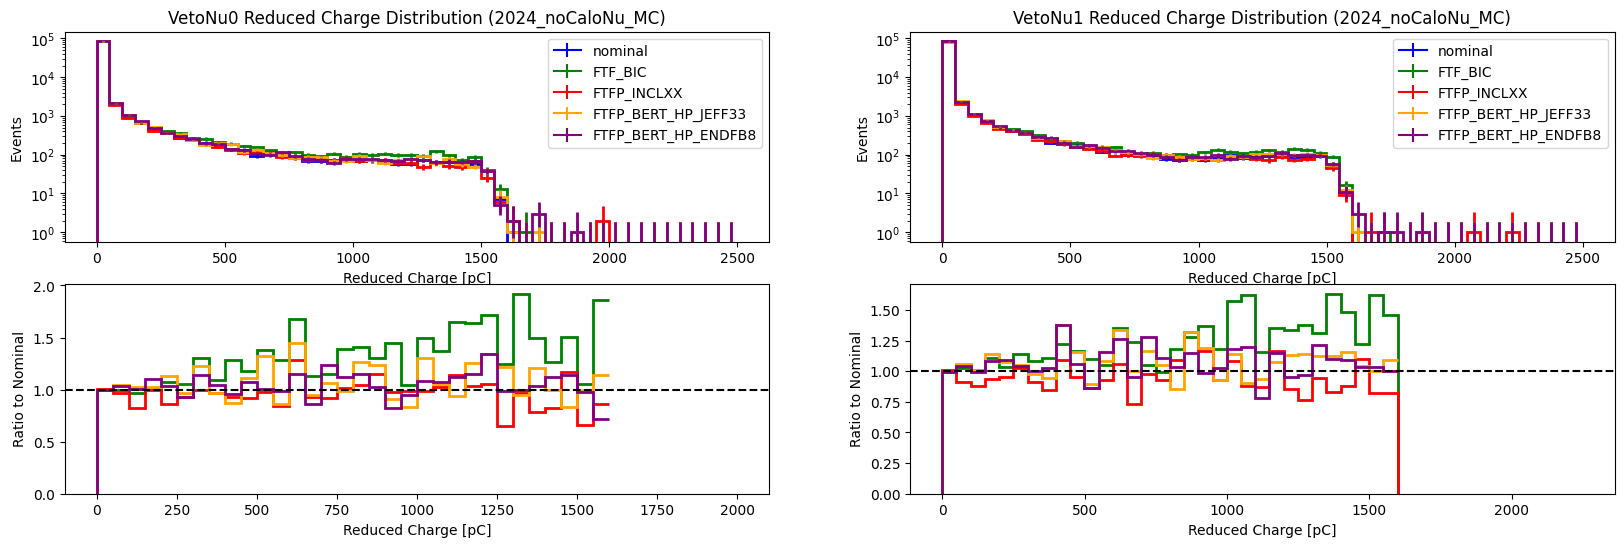

In [44]:
# Plot reduced charge distributions for VetoNu0 and VetoNu1 for each MC file
# 2022-2023:

fig, ax = plt.subplots(figsize=(20, 6), ncols=2, nrows=2)


h_VetoNu0_nom = None
h_VetoNu1_nom = None

rebin_factor = 50  # Adjust this factor as needed
period = "2024_noCaloNu_MC"

for mc_name, mc_info in MC_file_dict.items():

    file = mc_info[period]["file"]

    data = uproot.open(f"{file}:histograms")

    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    mplhep.histplot(h_VetoNu0, ax=ax[0][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(h_VetoNu1, ax=ax[0][1], label=mc_name, histtype="step", lw=2, color=color)

    if mc_name == "nominal":
        h_VetoNu0_nom = h_VetoNu0
        h_VetoNu1_nom = h_VetoNu1

for mc_name, mc_info in MC_file_dict.items():
    if mc_name == "nominal":
        continue

    file = mc_info[period]["file"]
    data = uproot.open(f"{file}:histograms")

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    ratio_VetoNu0 = h_VetoNu0 / h_VetoNu0_nom
    ratio_VetoNu1 = h_VetoNu1 / h_VetoNu1_nom

    mplhep.histplot(ratio_VetoNu0, ax=ax[1][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(ratio_VetoNu1, ax=ax[1][1], label=mc_name, histtype="step", lw=2, color=color)


ax[0][0].set_yscale("log")
ax[0][1].set_yscale("log")

ax[0][0].set_xlabel("Reduced Charge [pC]")
ax[0][1].set_xlabel("Reduced Charge [pC]")
ax[0][0].set_title(f"VetoNu0 Reduced Charge Distribution ({period})")
ax[0][1].set_title(f"VetoNu1 Reduced Charge Distribution ({period})")
ax[0][0].set_ylabel("Events")
ax[0][1].set_ylabel("Events")
ax[0][0].legend()
ax[0][1].legend();

ax[1][0].set_xlabel("Reduced Charge [pC]")
ax[1][1].set_xlabel("Reduced Charge [pC]")
ax[1][0].set_ylabel("Ratio to Nominal")
ax[1][1].set_ylabel("Ratio to Nominal")


ax[1][0].axhline(1, color="black", linestyle="--")
ax[1][1].axhline(1, color="black", linestyle="--")
    

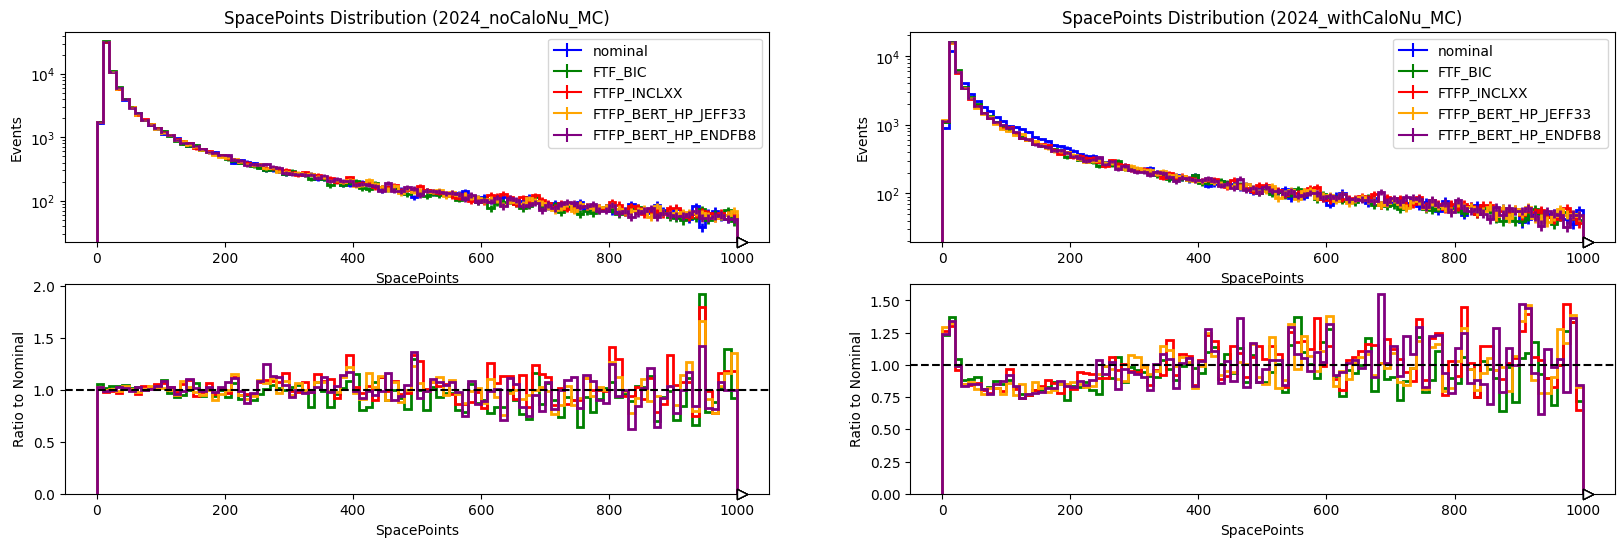

In [58]:
# Plot reduced charge distributions for VetoNu0 and VetoNu1 for each MC file
# 2022-2023:

fig, ax = plt.subplots(figsize=(20, 6), ncols=2, nrows=2)


h_VetoNu0_nom = None
h_VetoNu1_nom = None

rebin_factor = 1  # Adjust this factor as needed
period1 = "2024_noCaloNu_MC"
period2 = "2024_withCaloNu_MC"

for mc_name, mc_info in MC_file_dict.items():

    file1 = mc_info[period1]["file"]
    file2 = mc_info[period2]["file"]

    data1 = uproot.open(f"{file1}:histograms")
    data2 = uproot.open(f"{file2}:histograms")

    h_1 = data1["SpacePoints;1"].to_boost()[bh.rebin(rebin_factor)]
    h_2 = data2["SpacePoints;1"].to_boost()[bh.rebin(rebin_factor)]

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    mplhep.histplot(h_1, ax=ax[0][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(h_2, ax=ax[0][1], label=mc_name, histtype="step", lw=2, color=color)

    if mc_name == "nominal":
        h_1_nom = h_1
        h_2_nom = h_2

for mc_name, mc_info in MC_file_dict.items():
    if mc_name == "nominal":
        continue

    file1 = mc_info[period1]["file"]
    file2 = mc_info[period2]["file"]

    data1 = uproot.open(f"{file1}:histograms")
    data2 = uproot.open(f"{file2}:histograms")

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    h_1 = data1["SpacePoints;1"].to_boost()[bh.rebin(rebin_factor)]
    h_2 = data2["SpacePoints;1"].to_boost()[bh.rebin(rebin_factor)]

    ratio_1 = h_1 / h_1_nom
    ratio_2 = h_2 / h_2_nom

    mplhep.histplot(ratio_1, ax=ax[1][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(ratio_2, ax=ax[1][1], label=mc_name, histtype="step", lw=2, color=color)


ax[0][0].set_yscale("log")
ax[0][1].set_yscale("log")

ax[0][0].set_xlabel("SpacePoints")
ax[0][1].set_xlabel("SpacePoints")
ax[0][0].set_title(f"SpacePoints Distribution ({period1})")
ax[0][1].set_title(f"SpacePoints Distribution ({period2})")
ax[0][0].set_ylabel("Events")
ax[0][1].set_ylabel("Events")
ax[0][0].legend()
ax[0][1].legend();

ax[1][0].set_xlabel("SpacePoints")
ax[1][1].set_xlabel("SpacePoints")
ax[1][0].set_ylabel("Ratio to Nominal")
ax[1][1].set_ylabel("Ratio to Nominal")


ax[1][0].axhline(1, color="black", linestyle="--")
ax[1][1].axhline(1, color="black", linestyle="--")
    

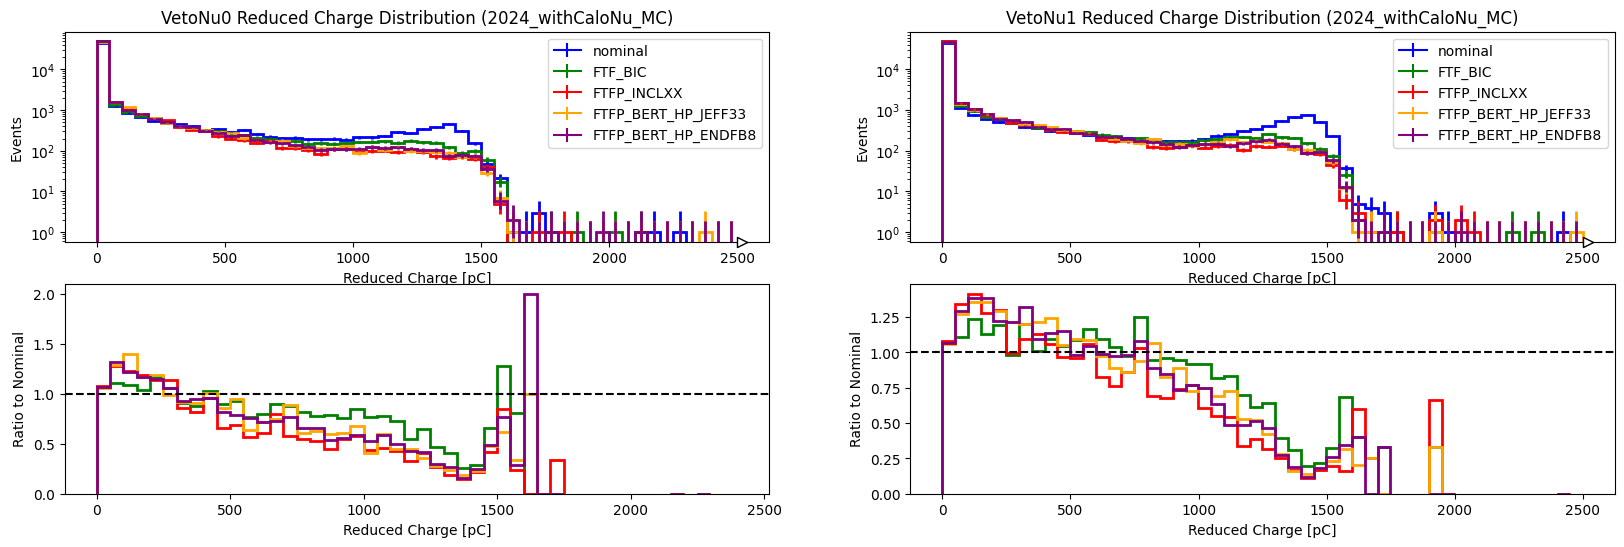

In [46]:
# Plot reduced charge distributions for VetoNu0 and VetoNu1 for each MC file
# 2022-2023:

fig, ax = plt.subplots(figsize=(20, 6), ncols=2, nrows=2)


h_VetoNu0_nom = None
h_VetoNu1_nom = None

rebin_factor = 50  # Adjust this factor as needed
period = "2024_withCaloNu_MC"

for mc_name, mc_info in MC_file_dict.items():

    file = mc_info[period]["file"]

    data = uproot.open(f"{file}:histograms")

    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    mplhep.histplot(h_VetoNu0, ax=ax[0][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(h_VetoNu1, ax=ax[0][1], label=mc_name, histtype="step", lw=2, color=color)

    if mc_name == "nominal":
        h_VetoNu0_nom = h_VetoNu0
        h_VetoNu1_nom = h_VetoNu1

for mc_name, mc_info in MC_file_dict.items():
    if mc_name == "nominal":
        continue

    file = mc_info[period]["file"]
    data = uproot.open(f"{file}:histograms")

    color = mc_info.get("color", "black")  # Default to black if no color specified
    
    h_VetoNu0 = data["VetoNu0_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]
    h_VetoNu1 = data["VetoNu1_reduced_charge"].to_boost()[bh.rebin(rebin_factor)]

    ratio_VetoNu0 = h_VetoNu0 / h_VetoNu0_nom
    ratio_VetoNu1 = h_VetoNu1 / h_VetoNu1_nom

    mplhep.histplot(ratio_VetoNu0, ax=ax[1][0], label=mc_name, histtype="step", lw=2, color=color)
    mplhep.histplot(ratio_VetoNu1, ax=ax[1][1], label=mc_name, histtype="step", lw=2, color=color)


ax[0][0].set_yscale("log")
ax[0][1].set_yscale("log")

ax[0][0].set_xlabel("Reduced Charge [pC]")
ax[0][1].set_xlabel("Reduced Charge [pC]")
ax[0][0].set_title(f"VetoNu0 Reduced Charge Distribution ({period})")
ax[0][1].set_title(f"VetoNu1 Reduced Charge Distribution ({period})")
ax[0][0].set_ylabel("Events")
ax[0][1].set_ylabel("Events")
ax[0][0].legend()
ax[0][1].legend();

ax[1][0].set_xlabel("Reduced Charge [pC]")
ax[1][1].set_xlabel("Reduced Charge [pC]")
ax[1][0].set_ylabel("Ratio to Nominal")
ax[1][1].set_ylabel("Ratio to Nominal")


ax[1][0].axhline(1, color="black", linestyle="--")
ax[1][1].axhline(1, color="black", linestyle="--")
    

In [47]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists/*.root")

calonu_data_files = []
non_caloNu_2024_data_files = []

for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])

    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    

In [48]:
hists_to_plot = [
    "VetoNu0_reduced_charge;1",
    "VetoNu1_reduced_charge;1",
]

In [49]:
histograms_noCaloNu = {}
for file in tqdm.tqdm(non_caloNu_2024_data_files):
    with uproot.open(file) as root_file:

        try:
            histograms_group = root_file['histograms']
        except KeyError:
            print(f"Warning: 'histograms' key not found in {file}. Skipping this file.")
            continue

        for hist_name, hist in root_file['histograms'].items():
            if hist_name in hists_to_plot:
                if hist_name not in histograms_noCaloNu:
                    histograms_noCaloNu[hist_name] = hist.to_boost()
                else:
                    histograms_noCaloNu[hist_name] += hist.to_boost()

histograms_CaloNu = {}
for file in tqdm.tqdm(calonu_data_files):

    with uproot.open(file) as root_file:
        try:
            histograms_group = root_file['histograms']
        except KeyError:
            print(f"Warning: 'histograms' key not found in {file}. Skipping this file.")
            continue

        for hist_name, hist in root_file['histograms'].items():
            if hist_name in hists_to_plot:
                if hist_name not in histograms_CaloNu:
                    histograms_CaloNu[hist_name] = hist.to_boost()
                else:
                    histograms_CaloNu[hist_name] += hist.to_boost()

 70%|███████   | 91/130 [00:04<00:01, 23.43it/s]

100%|██████████| 130/130 [00:06<00:00, 21.40it/s]


In [50]:
histograms_noCaloNu

{'VetoNu0_reduced_charge;1': Histogram(Regular(2501, -1, 2500), storage=Double()) # Sum: 823088342.0 (823110824.0 with flow),
 'VetoNu1_reduced_charge;1': Histogram(Regular(2501, -1, 2500), storage=Double()) # Sum: 823088338.0 (823110824.0 with flow)}

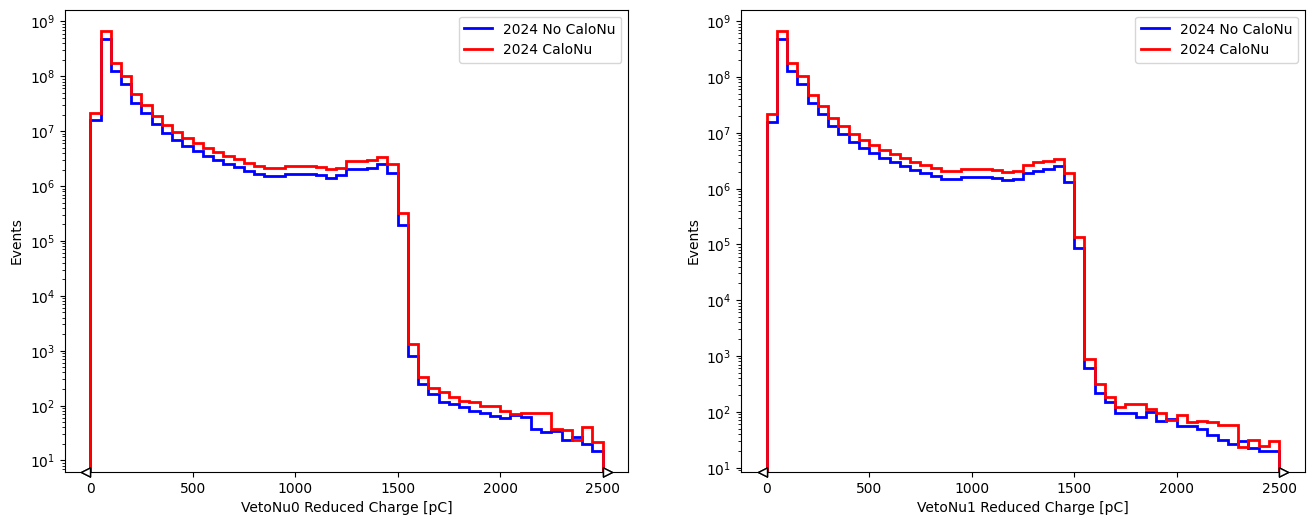

In [59]:
fig, ax = plt.subplots(figsize=(16, 6), ncols=2)

rebin_factor = 50  # Adjust this factor as needed

mplhep.histplot(histograms_noCaloNu["VetoNu0_reduced_charge;1"][bh.rebin(rebin_factor)], ax=ax[0], label="2024 No CaloNu", histtype="step", lw=2, color="blue")
mplhep.histplot(histograms_CaloNu["VetoNu0_reduced_charge;1"][bh.rebin(rebin_factor)], ax=ax[0], label="2024 CaloNu", histtype="step", lw=2, color="red")
mplhep.histplot(histograms_noCaloNu["VetoNu1_reduced_charge;1"][bh.rebin(rebin_factor)], ax=ax[1], label="2024 No CaloNu", histtype="step", lw=2, color="blue")
mplhep.histplot(histograms_CaloNu["VetoNu1_reduced_charge;1"][bh.rebin(rebin_factor)], ax=ax[1], label="2024 CaloNu", histtype="step", lw=2, color="red")

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].set_xlabel("VetoNu0 Reduced Charge [pC]")
ax[1].set_xlabel("VetoNu1 Reduced Charge [pC]")
ax[0].set_ylabel("Events")
ax[1].set_ylabel("Events")
ax[0].legend()
ax[1].legend()